In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, make_scorer
import json
import shap

def weighted_kmeans_clustering(df, k=10, location_vars=None, weights=None, size_var=None, id_col=None, random_state=42, max_iterations=100, verbose=None, init_centroids=None):
    """
    Desc: weighted K-means clustering to nearest centroid.
    
    ==========
    Parameters
    ==========
    df              : The dataframe containing data
    k               : Number of clusters to create
    location_vars   : List of column to use as location variables (default: all numeric columns)
    weights         : Variable used as weights (default: equal weights)
    size_var        : Column name to use for size weighting (default: None = equal weights of 1)
    id_col          : Column name for observation identification (default: None = use dataframe index)
    random_state    : Random seed
    max_iterations  : Maximum iterations
    verbose         : None (no output), 1 (summary only), 2 (full details)
    init_centroids  : data points (ex: [0, 5, 10]) or None for random initialization

    ==========
    Returns
    ==========
    cluster representatives dataframe
    """

    df = df.copy()

    # default size variable (all equal weights)
    if size_var is None:
        df['_temp_size_weight'] = 1.0
        size_var = '_temp_size_weight'
    
    # default id column (use index)
    if id_col is None:
        df['_temp_id'] = df.index
        id_col = '_temp_id'

    # determine which columns to use for clustering
    if location_vars is None:
        location_vars = df.select_dtypes(include=[np.number]).columns.tolist()
        # Remove size and id columns if they're in the numeric columns
        for col in [size_var, id_col, '_temp_size_weight', '_temp_id']:
            if col in location_vars:
                location_vars.remove(col)
            
    # set default weights (all features equally important)
    if weights is None:
        weights = {var: 1.0 for var in location_vars}
    
    # extract and standardize location data
    X_raw = df[location_vars].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    X_scaled_df = pd.DataFrame(X_scaled, columns=location_vars)
    
    # apply weights
    for var in location_vars:
        if var in weights:
            X_scaled_df[var] = X_scaled_df[var] * weights[var]
    
    X = X_scaled_df.values
    n_observations = len(X)

    # observation sizes and normalize weights
    size_weights = df[size_var].values
    normalized_weights = size_weights / size_weights.sum() * len(size_weights)
    

    # Initialize centroids
    if init_centroids is None:
        # random initialization
        np.random.seed(random_state)
        indices = np.random.choice(n_observations, k, replace=False)
        centroids = X[indices]
        init_method = "random"
    elif isinstance(init_centroids, list) and len(init_centroids) == k:
        # data points initialization
        indices = np.array(init_centroids)
        if np.any(indices >= n_observations) or np.any(indices < 0):
            raise ValueError(f"Initial centroid indices must be between 0 and {n_observations-1}")
        centroids = X[indices]
        init_method = "indices"
    else:
        raise ValueError(f"init_centroids must be None (random initialization) or a list of indices (ex: [0, 5, 10]) of length k={k}")
    
    if verbose is not None:
        print("=" * 50)
        print(f"INITIALIZATION")
        print("=" * 50)
        print(f"Number of clusters (k): {k}")
        print(f"Number of observations: {n_observations}")
        print(f"Number of features: {len(location_vars)}")
        print(f"Feature names: {location_vars}")
        print(f"Feature weights: {weights}")
        print(f"Initialization method: {init_method}")
        print(f"Random seed: {random_state}")
        print(f"Initial centroid indices: {indices}")
        if verbose >= 2:
            print(f"\nInitial centroid:")
            for i, centroid in enumerate(centroids):
                print(f"  Cluster {i}: {centroid}")
        print()
    
    # K-means iterations
    for iteration in range(max_iterations):
        # Calculate distance from each observation to each centroid
        distances = np.zeros((n_observations, k))
        
        for centroid_idx in range(k):
            centroid_position = centroids[centroid_idx]
            
            # calculate distance from each observation to this centroid
            for obs_idx in range(n_observations):
                obs_position = X[obs_idx]
                squared_differences = (obs_position - centroid_position) ** 2
                distance = np.sqrt(squared_differences.sum())
                distances[obs_idx, centroid_idx] = distance
        
        # assign each observation to nearest centroid
        labels = np.argmin(distances, axis=1)
        
        # Update centroids using weighted average
        new_centroids = np.zeros_like(centroids)
        
        for cluster_id in range(k):
            observations_in_cluster = (labels == cluster_id)
            
            if np.sum(observations_in_cluster) > 0:
                # calculate weighted average position of all observations in cluster
                cluster_points = X[observations_in_cluster]
                cluster_weights = normalized_weights[observations_in_cluster]
                new_centroids[cluster_id] = np.average(cluster_points, axis=0, weights=cluster_weights)
            else:
                # keep old centroid if cluster is empty
                new_centroids[cluster_id] = centroids[cluster_id]
        
        # convergence
        if verbose is not None:
            cluster_sizes = np.bincount(labels, minlength=k)
            print(f"Iteration {iteration + 1}:")
            print(f"  Cluster sizes: {cluster_sizes}")
            if verbose >= 2:
                print(f"New centroid positions:")
                for i, centroid in enumerate(new_centroids):
                    print(f"  Cluster {i}: {centroid}")
            print()
        
        if np.array_equal(new_centroids, centroids):
            if verbose is not None:
                print(f"Converged after {iteration + 1} iterations")
                print("=" * 50)
            break
        
        centroids = new_centroids
    else:
        if verbose is not None:
            print(f"Not converged after maximum iteration of = ({max_iterations})")
            print("=" * 50)
    
# find representative seriatim (nearest to centroid)
    df['cluster'] = labels
    representatives = []
    
    for cluster_id in range(k):
        observations_in_cluster = (labels == cluster_id)
        
        if np.sum(observations_in_cluster) > 0:
            # calculate distances from all points in a cluster to its centroid
            cluster_distances = np.linalg.norm(X[observations_in_cluster] - centroids[cluster_id], axis=1)
            
            # find observation with minimum distance
            closest_idx = np.where(observations_in_cluster)[0][np.argmin(cluster_distances)]
            cluster_weight_sum = df.loc[observations_in_cluster, size_var].sum()
            
            rep_info = {
                'cluster': cluster_id,
                'id': df.iloc[closest_idx][id_col],
                'cluster_size': np.sum(observations_in_cluster),
                'cluster_weight_sum': cluster_weight_sum
            }
            representatives.append(rep_info)
    
    return pd.DataFrame(representatives)

In [8]:
df = pd.read_excel('./SHEETS/k-means testing.xlsx', sheet_name='data_sample')
df = df.drop(columns=['No', 'cluster'])

result = weighted_kmeans_clustering(
    df=df,
    k=3,
    location_vars=['var_1', 'var_3'],
    weights={'var_1': 1, 'var_3': 1},
    random_state=42,
    verbose=2,
    init_centroids=[7, 8, 9]
)

print(result)


INITIALIZATION
Number of clusters (k): 3
Number of observations: 10
Number of features: 2
Feature names: ['var_1', 'var_3']
Feature weights: {'var_1': 1, 'var_3': 1}
Initialization method: indices
Random seed: 42
Initial centroid indices: [7 8 9]

Initial centroid:
  Cluster 0: [-0.41904997  1.35710229]
  Cluster 1: [-0.19253647 -1.1874645 ]
  Cluster 2: [-0.36242159 -1.61155897]

Iteration 1:
  Cluster sizes: [4 5 1]
New centroid positions:
  Cluster 0: [-0.68803474  0.93300782]
  Cluster 1: [ 0.62291211 -0.42409446]
  Cluster 2: [-0.36242159 -1.61155897]

Iteration 2:
  Cluster sizes: [5 3 2]
New centroid positions:
  Cluster 0: [-0.73616886  0.67855114]
  Cluster 1: [ 1.41193412 -0.19791075]
  Cluster 2: [-0.27747903 -1.39951173]

Iteration 3:
  Cluster sizes: [5 3 2]
New centroid positions:
  Cluster 0: [-0.73616886  0.67855114]
  Cluster 1: [ 1.41193412 -0.19791075]
  Cluster 2: [-0.27747903 -1.39951173]

Converged after 3 iterations
   cluster   id  cluster_size  cluster_weight_s

In [9]:
df = pd.read_excel('./SHEETS/k-means testing.xlsx', sheet_name='data_sample')
df = df.drop(columns=['No', 'cluster'])

result = weighted_kmeans_clustering(
    df=df,
    k=3,
    location_vars=['var_1', 'var_3'],
    weights={'var_1': 1, 'var_3': 3},
    random_state=42,
    verbose=2,
    init_centroids=[1, 5, 9]
)

print(result)


INITIALIZATION
Number of clusters (k): 3
Number of observations: 10
Number of features: 2
Feature names: ['var_1', 'var_3']
Feature weights: {'var_1': 1, 'var_3': 3}
Initialization method: indices
Random seed: 42
Initial centroid indices: [1 5 9]

Initial centroid:
  Cluster 0: [-0.92870533 -1.01782672]
  Cluster 1: [1.78945661 0.25445668]
  Cluster 2: [-0.36242159 -4.8346769 ]

Iteration 1:
  Cluster sizes: [4 4 2]
New centroid positions:
  Cluster 0: [-0.53230671 -0.38168502]
  Cluster 1: [0.67104623 2.48095262]
  Cluster 2: [-0.27747903 -4.1985352 ]

Iteration 2:
  Cluster sizes: [4 3 3]
New centroid positions:
  Cluster 0: [ 0.44453273 -0.06361417]
  Cluster 1: [-0.62668734  3.6472124 ]
  Cluster 2: [ 0.03397702 -3.5623935 ]

Iteration 3:
  Cluster sizes: [5 2 3]
New centroid positions:
  Cluster 0: [0.15855945 0.25445668]
  Cluster 1: [-0.44736415  4.70744856]
  Cluster 2: [ 0.03397702 -3.5623935 ]

Iteration 4:
  Cluster sizes: [5 2 3]
New centroid positions:
  Cluster 0: [0.1585

In [10]:
# Get only the representative indices from the result
representative_indices = result['id'].dropna().astype(int).tolist()

# Filter the original dataframe to keep only representatives
df_representatives = df.loc[representative_indices].copy()

# Add cluster and cluster_size information
cluster_size_map = dict(zip(result['cluster'], result['cluster_size']))
id_to_cluster = dict(zip(result['id'], result['cluster']))

df_representatives['cluster'] = df_representatives.index.map(id_to_cluster)
df_representatives['cluster_size'] = df_representatives['cluster'].map(cluster_size_map)
df_representatives = df_representatives.drop('cluster', axis=1)

print(df_representatives)

   var_1  var_2  var_3  cluster_size
0    300     30  50000             5
6   1000     20  90000             2
8   1500     30  20000             3


In [23]:
with open("PROCESSED/DATA/merged_and_dropped.cat_cols.json") as f:
    cat_cols = json.load(f)

X_train = pd.read_parquet("INPUTS/TRAIN/X_train.parquet")
X_test = pd.read_parquet("INPUTS/TEST/X_test.parquet")
y_train = pd.read_parquet("INPUTS/TRAIN/y_train.parquet")
y_test = pd.read_parquet("INPUTS/TEST/y_test.parquet")

X_train[cat_cols] = X_train[cat_cols].astype("category")
X_test[cat_cols] = X_test[cat_cols].astype("category")

num_cols = [c for c in X_train.columns if c not in cat_cols]

# encode
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# target
y_train_cat = y_train.iloc[:, 0].astype(int)
y_test_cat  = y_test.iloc[:, 0].astype(int)

# target
y_train_cat = y_train.iloc[:, 0].astype(int)
y_test_cat  = y_test.iloc[:, 0].astype(int)

# best parameters
best_params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 200,
    'subsample': 0.8
}

# model with best parameters
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    **best_params
)

# fit
xgb.fit(X_train_encoded, y_train_cat)

# evaluate
y_pred_train = xgb.predict(X_train_encoded)
y_pred_test  = xgb.predict(X_test_encoded)

acc_train = accuracy_score(y_train_cat, y_pred_train)
acc_test  = accuracy_score(y_test_cat, y_pred_test)

f1_train = f1_score(y_train_cat, y_pred_train, average='macro')
f1_test  = f1_score(y_test_cat, y_pred_test, average='macro')

auc_train = roc_auc_score(y_train_cat, xgb.predict_proba(X_train_encoded)[:, 1])
auc_test  = roc_auc_score(y_test_cat, xgb.predict_proba(X_test_encoded)[:, 1])

print(f"Train accuracy: {acc_train:.3f},  F1: {f1_train:.3f}, AUC: {auc_train:.3f}")
print(f"Test  accuracy: {acc_test:.3f},  F1: {f1_test:.3f}, AUC: {auc_test:.3f}")

print("\nClassification report:\n")
print(classification_report(y_test_cat, y_pred_test))

Train accuracy: 0.943,  F1: 0.889, AUC: 0.981
Test  accuracy: 0.912,  F1: 0.814, AUC: 0.938

Classification report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1642
           1       0.80      0.59      0.68       306

    accuracy                           0.91      1948
   macro avg       0.86      0.78      0.81      1948
weighted avg       0.91      0.91      0.91      1948



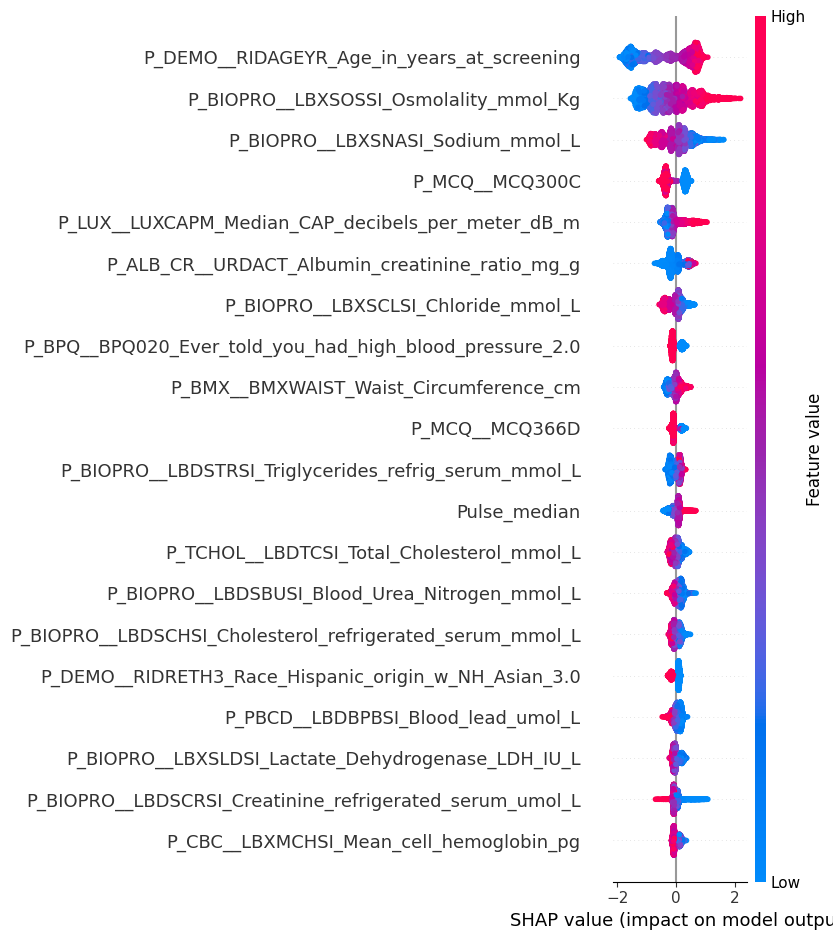

In [24]:
# 1. initialize explainer
explainer = shap.TreeExplainer(xgb)

# 2. compute SHAP values (main effects)
shap_values = explainer.shap_values(X_train_encoded)

# 3. global summary plot (main effects)
shap.summary_plot(shap_values, X_train_encoded, show=True)

In [28]:
# move shap feature importance to df
shap_vals = shap_values.values if hasattr(shap_values, "values") else shap_values
feature_importance = np.abs(shap_vals).mean(axis=0)

importance_df = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df)

# select top_n features for clustering
top_n = 20
top_features = importance_df['feature'].head(top_n).tolist()
top_features

                                               feature  importance
0           P_DEMO__RIDAGEYR_Age_in_years_at_screening    0.862510
27               P_BIOPRO__LBXSOSSI_Osmolality_mmol_Kg    0.629597
29                    P_BIOPRO__LBXSNASI_Sodium_mmol_L    0.425140
100                                     P_MCQ__MCQ300C    0.343155
11   P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m    0.258876
..                                                 ...         ...
215  P_DPQ__DPQ010_Have_little_interest_in_doing_th...    0.000000
216  P_DPQ__DPQ010_Have_little_interest_in_doing_th...    0.000000
217  P_DPQ__DPQ010_Have_little_interest_in_doing_th...    0.000000
219  P_DPQ__DPQ020_Feeling_down_depressed_or_hopele...    0.000000
374  P_WHQ__WHQ225_Times_lost_10_lbs_or_more_to_los...    0.000000

[375 rows x 2 columns]


['P_DEMO__RIDAGEYR_Age_in_years_at_screening',
 'P_BIOPRO__LBXSOSSI_Osmolality_mmol_Kg',
 'P_BIOPRO__LBXSNASI_Sodium_mmol_L',
 'P_MCQ__MCQ300C',
 'P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m',
 'P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g',
 'P_BIOPRO__LBXSCLSI_Chloride_mmol_L',
 'P_BPQ__BPQ020_Ever_told_you_had_high_blood_pressure_2.0',
 'P_BMX__BMXWAIST_Waist_Circumference_cm',
 'P_MCQ__MCQ366D',
 'P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L',
 'Pulse_median',
 'P_TCHOL__LBDTCSI_Total_Cholesterol_mmol_L',
 'P_BIOPRO__LBDSBUSI_Blood_Urea_Nitrogen_mmol_L',
 'P_BIOPRO__LBDSCHSI_Cholesterol_refrigerated_serum_mmol_L',
 'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0',
 'P_PBCD__LBDBPBSI_Blood_lead_umol_L',
 'P_BIOPRO__LBXSLDSI_Lactate_Dehydrogenase_LDH_IU_L',
 'P_BIOPRO__LBDSCRSI_Creatinine_refrigerated_serum_umol_L',
 'P_CBC__LBXMCHSI_Mean_cell_hemoglobin_pg']

In [31]:
# Apply clustering on X_train

k = int(len(X_train_encoded) * 0.10)    # set k to 10% of training data size

result = weighted_kmeans_clustering(
    df=X_train_encoded,
    k=k,
    location_vars=top_features,  # use only top SHAP features
    weights={feat: importance_df[importance_df['feature'] == feat]['importance'].values[0] 
             for feat in top_features},  # use SHAP importance as weights
    random_state=42,
    verbose=0,
    max_iterations=100,
    init_centroids=None
)

# Get representative indices and filter X_train
representative_indices = result['id'].dropna().astype(int).tolist()
X_train_representatives = X_train.loc[representative_indices].copy()

# Add cluster_size
cluster_size_map = dict(zip(result['id'], result['cluster_size']))
X_train_representatives['cluster_size'] = X_train_representatives.index.map(cluster_size_map)

print(X_train_representatives)

INITIALIZATION
Number of clusters (k): 778
Number of observations: 7789
Number of features: 20
Feature names: ['P_DEMO__RIDAGEYR_Age_in_years_at_screening', 'P_BIOPRO__LBXSOSSI_Osmolality_mmol_Kg', 'P_BIOPRO__LBXSNASI_Sodium_mmol_L', 'P_MCQ__MCQ300C', 'P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m', 'P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g', 'P_BIOPRO__LBXSCLSI_Chloride_mmol_L', 'P_BPQ__BPQ020_Ever_told_you_had_high_blood_pressure_2.0', 'P_BMX__BMXWAIST_Waist_Circumference_cm', 'P_MCQ__MCQ366D', 'P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L', 'Pulse_median', 'P_TCHOL__LBDTCSI_Total_Cholesterol_mmol_L', 'P_BIOPRO__LBDSBUSI_Blood_Urea_Nitrogen_mmol_L', 'P_BIOPRO__LBDSCHSI_Cholesterol_refrigerated_serum_mmol_L', 'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0', 'P_PBCD__LBDBPBSI_Blood_lead_umol_L', 'P_BIOPRO__LBXSLDSI_Lactate_Dehydrogenase_LDH_IU_L', 'P_BIOPRO__LBDSCRSI_Creatinine_refrigerated_serum_umol_L', 'P_CBC__LBXMCHSI_Mean_cell_hemoglobin_pg']
Feature weigh

KeyboardInterrupt: 

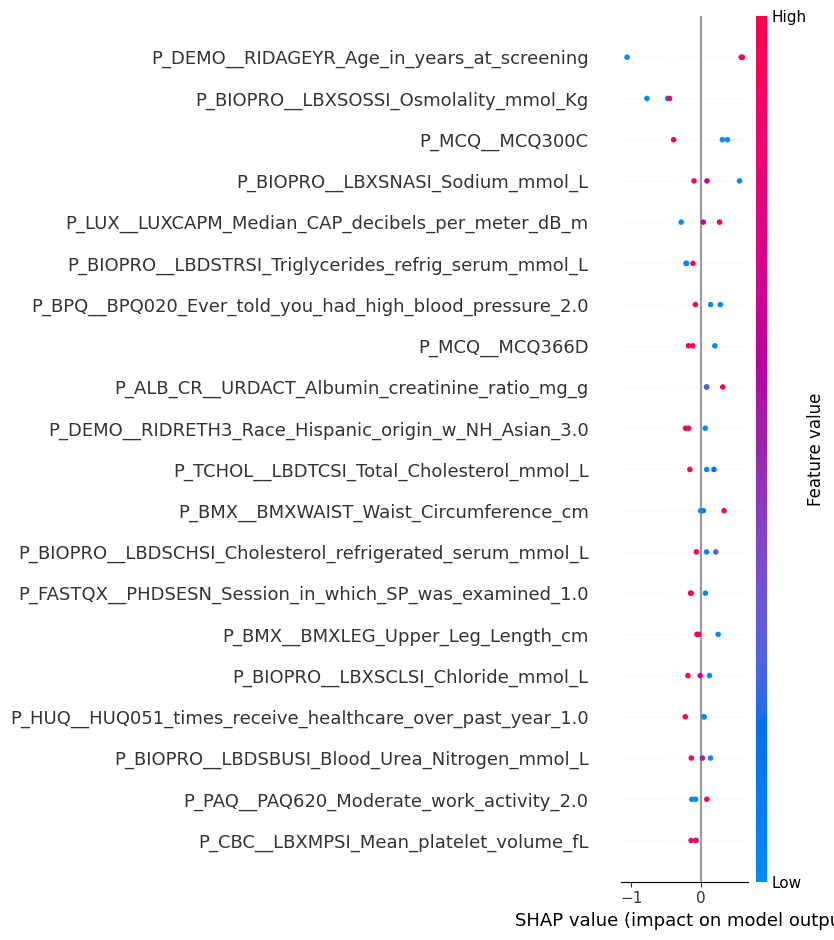

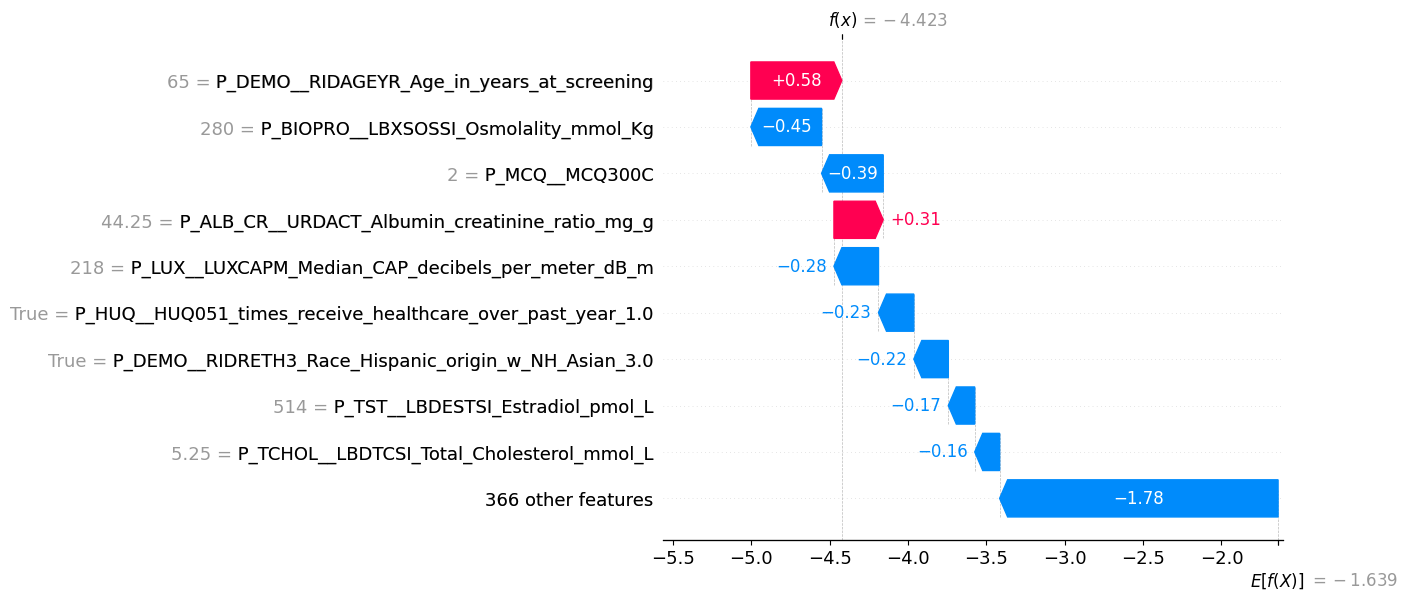

In [18]:
# Encode the representative samples (same way as training)
X_train_representatives_encoded = pd.get_dummies(X_train_representatives, drop_first=True)
X_train_representatives_encoded = X_train_representatives_encoded.reindex(columns=X_encoded.columns, fill_value=0)

# Use the already fitted model (xgb) to get SHAP values
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_train_representatives_encoded)

# Visualize
shap.summary_plot(shap_values, X_train_representatives_encoded, show=True)
shap.waterfall_plot(shap_values[0])  # For first representative